<a href="https://colab.research.google.com/github/prksh830/Healthcare/blob/main/Copy_of_HGWGO_AAME_CVD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
cvd = pd.read_csv("CVD_cleaned.csv")
cvd = cvd.drop_duplicates()

In [3]:
y = cvd["Heart_Disease"]

In [4]:
X = cvd.drop("Heart_Disease", axis=1)

In [5]:
import pandas as pd

cvd = pd.read_csv("CVD_cleaned.csv")
cvd = cvd.drop_duplicates().reset_index(drop=True)

print(cvd.shape)
print(cvd.dtypes)

(308774, 19)
General_Health                   object
Checkup                          object
Exercise                         object
Skin_Cancer                      object
Other_Cancer                     object
Depression                       object
Diabetes                         object
Arthritis                        object
Sex                              object
Age_Category                     object
Height_(cm)                       int64
Weight_(kg)                     float64
BMI                             float64
Smoking_History                  object
Alcohol_Consumption               int64
Fruit_Consumption                 int64
Green_Vegetables_Consumption      int64
FriedPotato_Consumption           int64
Heart_Disease                    object
dtype: object


In [6]:
print(cvd["Heart_Disease"].value_counts())

Heart_Disease
No     283803
Yes     24971
Name: count, dtype: int64


In [7]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [8]:
cvd = pd.read_csv("CVD_cleaned.csv")

cvd = cvd.drop_duplicates().reset_index(drop=True)

print(cvd.shape)

(308774, 19)


In [9]:
cvd["Heart_Disease"] = cvd["Heart_Disease"].map({
    "No":0,
    "Yes":1
})

In [10]:
cat_cols = cvd.select_dtypes(include="object").columns.tolist()

print(cat_cols)
print("Number of categorical columns:", len(cat_cols))

['General_Health', 'Checkup', 'Exercise', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex', 'Age_Category', 'Smoking_History']
Number of categorical columns: 11


In [11]:
encoders = {}

for col in cat_cols:

    le = LabelEncoder()

    cvd[col] = le.fit_transform(cvd[col])

    encoders[col] = le

In [12]:
X = cvd.drop("Heart_Disease", axis=1)

y = cvd["Heart_Disease"]

print(X.shape)
print(y.shape)

(308774, 18)
(308774,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(247019, 18)
(61755, 18)


In [14]:
!pip install -q imbalanced-learn

In [15]:
from imblearn.over_sampling import SMOTENC

In [16]:
cat_indices = [
    X.columns.get_loc(col)
    for col in cat_cols
]

In [17]:
X = cvd.drop("Heart_Disease", axis=1)
y = cvd["Heart_Disease"]

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [20]:
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(247019, 18)
(61755, 18)
Heart_Disease
0    227042
1     19977
Name: count, dtype: int64
Heart_Disease
0    56761
1     4994
Name: count, dtype: int64


In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix
)

pred = rf.predict(X_test)
prob = rf.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test,pred))
print("Precision:", precision_score(y_test,pred))
print("Recall   :", recall_score(y_test,pred))
print("F1       :", f1_score(y_test,pred))
print("AUROC    :", roc_auc_score(y_test,prob))
print("MCC      :", matthews_corrcoef(y_test,pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test,pred))

Accuracy : 0.9189053517933771
Precision: 0.472
Recall   : 0.023628354024829795
F1       : 0.04500381388253242
AUROC    : 0.8222890547884396
MCC      : 0.09146628490081928

Confusion Matrix
[[56629   132]
 [ 4876   118]]


In [23]:
import numpy as np

thresholds = [0.10,0.15,0.20,0.25,0.30]

for t in thresholds:

    pred_t = (prob >= t).astype(int)

    print("\nThreshold:", t)

    print("Precision:",
          precision_score(y_test,pred_t))

    print("Recall:",
          recall_score(y_test,pred_t))

    print("F1:",
          f1_score(y_test,pred_t))

    print("MCC:",
          matthews_corrcoef(y_test,pred_t))


Threshold: 0.1
Precision: 0.2103832870973221
Recall: 0.7440929114937925
F1: 0.32802224478086245
MCC: 0.3006743543194793

Threshold: 0.15
Precision: 0.2555450073358074
Recall: 0.592911493792551
F1: 0.35715578071286413
MCC: 0.3079149849833999

Threshold: 0.2
Precision: 0.29249119002439683
Recall: 0.43211854225070084
F1: 0.348852247009376
MCC: 0.285922221354188

Threshold: 0.25
Precision: 0.32734746862829944
Recall: 0.30296355626752103
F1: 0.3146838602329451
MCC: 0.2571432557806713

Threshold: 0.3
Precision: 0.3669889008234873
Recall: 0.2052462955546656
F1: 0.26325927828432
MCC: 0.22841355250281453


In [24]:
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [25]:
from xgboost import XGBClassifier

In [26]:
from lightgbm import LGBMClassifier

In [27]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.9 MB/s eta 0:00:00


In [28]:
from catboost import CatBoostClassifier

In [29]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=100
)

In [30]:
cat.fit(
    X_train,
    y_train
)

0:	total: 121ms	remaining: 36.1s
100:	total: 13.7s	remaining: 27s
200:	total: 27.5s	remaining: 13.6s
299:	total: 37.5s	remaining: 0us


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=300, learning_rate=0.1, loss_function='Logloss', verbose=100)

In [31]:
pred = cat.predict(X_test)

prob = cat.predict_proba(X_test)[:,1]

from sklearn.metrics import *

print("Accuracy :", accuracy_score(y_test,pred))
print("Precision:", precision_score(y_test,pred))
print("Recall   :", recall_score(y_test,pred))
print("F1       :", f1_score(y_test,pred))
print("AUROC    :", roc_auc_score(y_test,prob))
print("MCC      :", matthews_corrcoef(y_test,pred))

Accuracy : 0.9198445470002429
Precision: 0.5632183908045977
Recall   : 0.03924709651581898
F1       : 0.07338075627105953
AUROC    : 0.8406125475339175
MCC      : 0.13318833905435423


In [32]:
from sklearn.metrics import *

thresholds = [0.05,0.10,0.15,0.20,0.25,0.30]

for t in thresholds:

    pred_t = (prob >= t).astype(int)

    print("\nThreshold:", t)

    print("Precision:",
          precision_score(y_test,pred_t))

    print("Recall:",
          recall_score(y_test,pred_t))

    print("F1:",
          f1_score(y_test,pred_t))

    print("MCC:",
          matthews_corrcoef(y_test,pred_t))


Threshold: 0.05
Precision: 0.16846717534184483
Recall: 0.8930716860232278
F1: 0.2834625651455447
MCC: 0.278331565931834

Threshold: 0.1
Precision: 0.22118722517935663
Recall: 0.7655186223468162
F1: 0.34320854654816413
MCC: 0.3208661212815617

Threshold: 0.15
Precision: 0.26823387582881253
Recall: 0.6237484981978374
F1: 0.3751430119828988
MCC: 0.33073857247774263

Threshold: 0.2
Precision: 0.30797290255341325
Recall: 0.47336804164998
F1: 0.37316495659037097
MCC: 0.3138358901329007

Threshold: 0.25
Precision: 0.34780035509962515
Recall: 0.35302362835402484
F1: 0.3503925270793998
MCC: 0.2927840294920592

Threshold: 0.3
Precision: 0.39408866995073893
Recall: 0.2563075690828995
F1: 0.3106042222761466
MCC: 0.2706932475878939


In [33]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [34]:
pred = xgb.predict(X_test)

prob = xgb.predict_proba(X_test)[:,1]

from sklearn.metrics import *

print("Accuracy :", accuracy_score(y_test,pred))
print("Precision:", precision_score(y_test,pred))
print("Recall   :", recall_score(y_test,pred))
print("F1       :", f1_score(y_test,pred))
print("AUROC    :", roc_auc_score(y_test,prob))
print("MCC      :", matthews_corrcoef(y_test,pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test,pred))

Accuracy : 0.9194559145008502
Precision: 0.521551724137931
Recall   : 0.048458149779735685
F1       : 0.0886771711249542
AUROC    : 0.8378130499433308
MCC      : 0.14064054441740248

Confusion Matrix
[[56539   222]
 [ 4752   242]]


In [35]:
thresholds = [0.05,0.10,0.15,0.20,0.25,0.30]

for t in thresholds:

    pred_t = (prob >= t).astype(int)

    print("\nThreshold:", t)

    print("Precision:",
          precision_score(y_test,pred_t))

    print("Recall:",
          recall_score(y_test,pred_t))

    print("F1:",
          f1_score(y_test,pred_t))

    print("MCC:",
          matthews_corrcoef(y_test,pred_t))


Threshold: 0.05
Precision: 0.17151050143377508
Recall: 0.8862635162194633
F1: 0.2874025974025974
MCC: 0.28169031709535586

Threshold: 0.1
Precision: 0.2213691243699449
Recall: 0.7563075690828995
F1: 0.34249183895538626
MCC: 0.3184183004256647

Threshold: 0.15
Precision: 0.263891293058681
Recall: 0.6105326391670004
F1: 0.3685037466763355
MCC: 0.32206188382311696

Threshold: 0.2
Precision: 0.30371713508612874
Recall: 0.4695634761714057
F1: 0.3688556822650413
MCC: 0.30898479835914766

Threshold: 0.25
Precision: 0.33714721586575136
Recall: 0.3540248297957549
F1: 0.345379957022856
MCC: 0.286352620222031

Threshold: 0.3
Precision: 0.38439635535307515
Recall: 0.27032438926712055
F1: 0.31742299553256526
MCC: 0.2733868174804315


In [36]:
from sklearn.ensemble import ExtraTreesClassifier

In [37]:
from sklearn.ensemble import ExtraTreesClassifier

et = ExtraTreesClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

et.fit(X_train, y_train)

pred = et.predict(X_test)
prob = et.predict_proba(X_test)[:,1]

In [38]:
print("Extra Trees Training Completed")

Extra Trees Training Completed


In [39]:
from sklearn.metrics import *

pred = et.predict(X_test)

prob = et.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test,pred))
print("Precision:", precision_score(y_test,pred))
print("Recall   :", recall_score(y_test,pred))
print("F1       :", f1_score(y_test,pred))
print("AUROC    :", roc_auc_score(y_test,prob))
print("MCC      :", matthews_corrcoef(y_test,pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test,pred))

Accuracy : 0.9172374706501498
Precision: 0.40134907251264756
Recall   : 0.04765718862635162
F1       : 0.08519778056201897
AUROC    : 0.8101040869910332
MCC      : 0.11574754917594227

Confusion Matrix
[[56406   355]
 [ 4756   238]]


In [40]:
thresholds = [0.05,0.10,0.15,0.20,0.25,0.30]

for t in thresholds:

    pred_t = (prob >= t).astype(int)

    print("\nThreshold:", t)

    print("Precision:",
          precision_score(y_test,pred_t))

    print("Recall:",
          recall_score(y_test,pred_t))

    print("F1:",
          f1_score(y_test,pred_t))

    print("MCC:",
          matthews_corrcoef(y_test,pred_t))


Threshold: 0.05
Precision: 0.1623540966267518
Recall: 0.8606327593111734
F1: 0.27317507229796295
MCC: 0.25889974508677177

Threshold: 0.1
Precision: 0.20457006097213518
Recall: 0.7188626351621946
F1: 0.31850241760191633
MCC: 0.28588116322713203

Threshold: 0.15
Precision: 0.23679447095606385
Recall: 0.5762915498598318
F1: 0.33566596687660366
MCC: 0.2831113222931175

Threshold: 0.2
Precision: 0.26788486802818584
Recall: 0.4491389667601121
F1: 0.33560260342634846
MCC: 0.2716732437984775

Threshold: 0.25
Precision: 0.2944859975647939
Recall: 0.3390068081698038
F1: 0.31518197896304573
MCC: 0.2510381142610263

Threshold: 0.3
Precision: 0.32380216383307575
Recall: 0.25170204245094113
F1: 0.2832356917530419
MCC: 0.23078166178988013


In [41]:
import joblib

joblib.dump(rf,  'RF_model.pkl')
joblib.dump(xgb, 'XGB_model.pkl')
joblib.dump(cat, 'CAT_model.pkl')
joblib.dump(et,  'ET_model.pkl')

print("Models Saved")

Models Saved


In [42]:
print(type(rf))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [43]:
print("rf" in globals())
print("xgb" in globals())
print("cat" in globals())
print("et" in globals())

True
True
True
True


In [44]:
import joblib

joblib.dump(X_train,'X_train.pkl')
joblib.dump(X_test,'X_test.pkl')

joblib.dump(y_train,'y_train.pkl')
joblib.dump(y_test,'y_test.pkl')

joblib.dump(encoders,'encoders.pkl')

['encoders.pkl']

In [45]:
import pandas as pd

results = pd.DataFrame({
    "Model":["RF","XGB","CAT","ET"],
    "AUROC":[0.8223,0.8378,0.8406,0.8101],
    "Best_F1":[0.3572,0.3689,0.3751,0.3356],
    "Best_MCC":[0.3079,0.3221,0.3307,0.2717]
})

results.to_csv("Baseline_Results.csv",index=False)
results

,Model,AUROC,Best_F1,Best_MCC
0,RF,0.8223,0.3572,0.3079
1,XGB,0.8378,0.3689,0.3221
2,CAT,0.8406,0.3751,0.3307
3,ET,0.8101,0.3356,0.2717


In [46]:
print(globals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', '_', '__', '___', '_i', '_ii', '_iii', '_i1', 'pd', 'np', '_i2', 'cvd', '_i3', 'y', '_i4', 'X', '_i5', '_i6', '_i7', 'train_test_split', 'LabelEncoder', '_i8', '_i9', '_i10', 'cat_cols', '_i11', 'encoders', 'col', 'le', '_i12', '_i13', 'X_train', 'X_test', 'y_train', 'y_test', '_i14', '_exit_code', '_i15', 'SMOTENC', '_i16', 'cat_indices', '_i17', '_i18', '_i19', 'RandomForestClassifier', 'rf', '_19', '_i20', '_i21', '_21', '_i22', 'accuracy_score', 'precision_score', 'recall_score', 'f1_score', 'roc_auc_score', 'matthews_corrcoef', 'confusion_matrix', 'pred', 'prob', '_i23', 'thresholds', 't', 'pred_t', '_i24', 'ExtraTreesClassifier', 'et', '_i25', 'XGBClassifier', '_i26', 'LGBMClassifier', '_i27', '_i28', 'CatBoostClassifier', '_i29', 'cat', '_i30', '_30', '_i31', 'adjusted_mutual_info_score', 'adjusted_rand_score',

In [47]:
print("xgb" in globals())
print("cat" in globals())
print("et" in globals())

True
True
True


In [48]:
import joblib

# data
joblib.dump(X_train, 'X_train.pkl')
joblib.dump(X_test,  'X_test.pkl')
joblib.dump(y_train, 'y_train.pkl')
joblib.dump(y_test,  'y_test.pkl')

# encoders
joblib.dump(encoders, 'encoders.pkl')

# models only if present in memory
if 'cat' in globals():
    joblib.dump(cat, 'CAT_model.pkl')

if 'xgb' in globals():
    joblib.dump(xgb, 'XGB_model.pkl')

if 'et' in globals():
    joblib.dump(et, 'ET_model.pkl')

if 'rf' in globals():
    joblib.dump(rf, 'RF_model.pkl')

print("Saved available artifacts.")

Saved available artifacts.


In [49]:
import pandas as pd

baseline_results = pd.DataFrame({
    "Model": ["RF", "XGB", "CAT", "ET"],
    "AUROC": [0.8223, 0.8378, 0.8406, 0.8101],
    "Best_F1": [0.3572, 0.3689, 0.3751, 0.3356],
    "Best_MCC": [0.3079, 0.3221, 0.3307, 0.2717],
    "Best_Threshold": [0.15, 0.20, 0.15, 0.20]
})

baseline_results.to_csv("Baseline_Results.csv", index=False)
baseline_results

,Model,AUROC,Best_F1,Best_MCC,Best_Threshold
0,RF,0.8223,0.3572,0.3079,0.15
1,XGB,0.8378,0.3689,0.3221,0.20
2,CAT,0.8406,0.3751,0.3307,0.15
3,ET,0.8101,0.3356,0.2717,0.20


In [52]:
print("X_train exists:", 'X_train' in globals())
print("X_test exists :", 'X_test' in globals())
print("y_train exists:", 'y_train' in globals())
print("y_test exists :", 'y_test' in globals())

print("cat exists    :", 'cat' in globals())
print("xgb exists    :", 'xgb' in globals())
print("rf exists     :", 'rf' in globals())
print("et exists     :", 'et' in globals())

X_train exists: True
X_test exists : True
y_train exists: True
y_test exists : True
cat exists    : True
xgb exists    : True
rf exists     : True
et exists     : True


In [53]:
feature_names = X_train.columns.tolist()
n_features = len(feature_names)

print("Number of features:", n_features)
print(feature_names)

Number of features: 18
['General_Health', 'Checkup', 'Exercise', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex', 'Age_Category', 'Height_(cm)', 'Weight_(kg)', 'BMI', 'Smoking_History', 'Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption']


In [54]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, matthews_corrcoef
import numpy as np

BEST_THRESHOLD = 0.15   # based on yesterday's CatBoost threshold sweep

def evaluate_feature_subset(mask, X_train, y_train, X_test, y_test):
    mask = np.array(mask).astype(int)

    # avoid empty feature subset
    if mask.sum() == 0:
        return 0.0, 0.0, 0.0, []

    selected_cols = X_train.columns[mask == 1].tolist()

    Xtr = X_train[selected_cols]
    Xte = X_test[selected_cols]

    model = CatBoostClassifier(
        iterations=150,
        depth=6,
        learning_rate=0.1,
        loss_function='Logloss',
        eval_metric='AUC',
        verbose=0,
        random_state=42
    )

    model.fit(Xtr, y_train)

    prob = model.predict_proba(Xte)[:, 1]
    pred = (prob >= BEST_THRESHOLD).astype(int)

    auc = roc_auc_score(y_test, prob)
    mcc = matthews_corrcoef(y_test, pred)

    fitness = 0.7 * auc + 0.3 * mcc

    return fitness, auc, mcc, selected_cols

In [55]:
full_mask = [1] * n_features

fitness, auc, mcc, selected_cols = evaluate_feature_subset(
    full_mask,
    X_train, y_train,
    X_test, y_test
)

print("Fitness :", fitness)
print("AUROC   :", auc)
print("MCC     :", mcc)
print("Features:", len(selected_cols))
print(selected_cols)

Fitness : 0.6884693300360392
AUROC   : 0.8413758531696431
MCC     : 0.33168744272429646
Features: 18
['General_Health', 'Checkup', 'Exercise', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex', 'Age_Category', 'Height_(cm)', 'Weight_(kg)', 'BMI', 'Smoking_History', 'Alcohol_Consumption', 'Fruit_Consumption', 'Green_Vegetables_Consumption', 'FriedPotato_Consumption']


In [56]:
import random

POP_SIZE = 10
MAX_ITER = 5

def initialize_population(pop_size, n_features):
    population = []

    for _ in range(pop_size):
        # ensure at least one feature is selected
        individual = np.random.randint(0, 2, size=n_features)
        if individual.sum() == 0:
            individual[np.random.randint(0, n_features)] = 1

        population.append(individual.tolist())

    return population

population = initialize_population(POP_SIZE, n_features)

print("Population size:", len(population))
print("Sample individual:", population[0])

Population size: 10
Sample individual: [1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1]


In [57]:
population_scores = []

for idx, individual in enumerate(population):
    fitness, auc, mcc, selected_cols = evaluate_feature_subset(
        individual,
        X_train, y_train,
        X_test, y_test
    )

    population_scores.append({
        "index": idx,
        "mask": individual,
        "fitness": fitness,
        "auc": auc,
        "mcc": mcc,
        "n_features": len(selected_cols),
        "features": selected_cols
    })

results_df = pd.DataFrame(population_scores).sort_values(
    by="fitness",
    ascending=False
).reset_index(drop=True)

results_df.head()

,index,mask,fitness,auc,mcc,n_features,features
0,2,"[1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, ...",0.678447,0.833507,0.316642,10,"[General_Health, Exercise, Skin_Cancer, Other_..."
1,8,"[1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, ...",0.674132,0.830424,0.309450,11,"[General_Health, Skin_Cancer, Other_Cancer, De..."
2,1,"[1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, ...",0.668664,0.826193,0.301097,10,"[General_Health, Checkup, Exercise, Skin_Cance..."
3,5,"[0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, ...",0.644814,0.805560,0.269739,10,"[Checkup, Skin_Cancer, Arthritis, Sex, Age_Cat..."
4,0,"[1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, ...",0.637269,0.793354,0.273069,11,"[General_Health, Checkup, Skin_Cancer, Other_C..."


In [58]:
best_row = results_df.iloc[0]

print("Best Initial Fitness :", best_row["fitness"])
print("Best Initial AUROC   :", best_row["auc"])
print("Best Initial MCC     :", best_row["mcc"])
print("No. of Features      :", best_row["n_features"])
print("Selected Features    :", best_row["features"])

Best Initial Fitness : 0.6784473883330695
Best Initial AUROC   : 0.8335066349099725
Best Initial MCC     : 0.3166424796536294
No. of Features      : 10
Selected Features    : ['General_Health', 'Exercise', 'Skin_Cancer', 'Other_Cancer', 'Diabetes', 'Sex', 'Age_Category', 'Weight_(kg)', 'BMI', 'FriedPotato_Consumption']


In [59]:
import copy
import numpy as np
import pandas as pd
import random

In [60]:
def ensure_non_empty(mask):
    mask = np.array(mask).astype(int)

    if mask.sum() == 0:
        idx = np.random.randint(0, len(mask))
        mask[idx] = 1

    return mask.tolist()

In [61]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [62]:
def binary_gwo_update(current, alpha, beta, delta, a):
    current = np.array(current)
    alpha = np.array(alpha)
    beta = np.array(beta)
    delta = np.array(delta)

    new_mask = []

    for j in range(len(current)):
        # alpha influence
        r1, r2 = np.random.rand(), np.random.rand()
        A1 = 2 * a * r1 - a
        C1 = 2 * r2
        D_alpha = abs(C1 * alpha[j] - current[j])
        X1 = alpha[j] - A1 * D_alpha

        # beta influence
        r1, r2 = np.random.rand(), np.random.rand()
        A2 = 2 * a * r1 - a
        C2 = 2 * r2
        D_beta = abs(C2 * beta[j] - current[j])
        X2 = beta[j] - A2 * D_beta

        # delta influence
        r1, r2 = np.random.rand(), np.random.rand()
        A3 = 2 * a * r1 - a
        C3 = 2 * r2
        D_delta = abs(C3 * delta[j] - current[j])
        X3 = delta[j] - A3 * D_delta

        X_avg = (X1 + X2 + X3) / 3.0

        prob = sigmoid(X_avg)

        bit = 1 if np.random.rand() < prob else 0
        new_mask.append(bit)

    return ensure_non_empty(new_mask)

In [63]:
def crossover(parent1, parent2):
    parent1 = np.array(parent1)
    parent2 = np.array(parent2)

    point = np.random.randint(1, len(parent1) - 1)

    child1 = np.concatenate([parent1[:point], parent2[point:]])
    child2 = np.concatenate([parent2[:point], parent1[point:]])

    return ensure_non_empty(child1), ensure_non_empty(child2)

In [64]:
def mutate(mask, mutation_rate=0.1):
    mask = np.array(mask).copy()

    for i in range(len(mask)):
        if np.random.rand() < mutation_rate:
            mask[i] = 1 - mask[i]

    return ensure_non_empty(mask)

In [65]:
def evaluate_population(population, X_train, y_train, X_test, y_test):
    pop_results = []

    for individual in population:
        fitness, auc, mcc, selected_cols = evaluate_feature_subset(
            individual,
            X_train, y_train,
            X_test, y_test
        )

        pop_results.append({
            "mask": individual,
            "fitness": fitness,
            "auc": auc,
            "mcc": mcc,
            "n_features": len(selected_cols),
            "features": selected_cols
        })

    pop_df = pd.DataFrame(pop_results).sort_values(
        by="fitness",
        ascending=False
    ).reset_index(drop=True)

    return pop_df

In [66]:
POP_SIZE = 10
MAX_ITER = 5
MUTATION_RATE = 0.10

population = initialize_population(POP_SIZE, n_features)

history = []

best_global_fitness = -1
best_global_solution = None

for iteration in range(MAX_ITER):
    print(f"\n========== Iteration {iteration+1}/{MAX_ITER} ==========")

    # Step 1: evaluate current population
    pop_df = evaluate_population(
        population,
        X_train, y_train,
        X_test, y_test
    )

    # Step 2: identify alpha, beta, delta
    alpha = pop_df.iloc[0]["mask"]
    beta  = pop_df.iloc[1]["mask"]
    delta = pop_df.iloc[2]["mask"]

    alpha_fit = pop_df.iloc[0]["fitness"]
    alpha_auc = pop_df.iloc[0]["auc"]
    alpha_mcc = pop_df.iloc[0]["mcc"]

    print("Best Fitness:", alpha_fit)
    print("Best AUROC  :", alpha_auc)
    print("Best MCC    :", alpha_mcc)
    print("Best Features:", pop_df.iloc[0]["n_features"])

    # store history
    history.append({
        "iteration": iteration + 1,
        "best_fitness": alpha_fit,
        "best_auc": alpha_auc,
        "best_mcc": alpha_mcc,
        "best_n_features": pop_df.iloc[0]["n_features"],
        "best_features": pop_df.iloc[0]["features"]
    })

    # update global best
    if alpha_fit > best_global_fitness:
        best_global_fitness = alpha_fit
        best_global_solution = copy.deepcopy(pop_df.iloc[0])

    # Step 3: Grey Wolf coefficient
    a = 2 - iteration * (2 / MAX_ITER)

    # Step 4: generate next population
    new_population = []

    # keep elite solutions
    new_population.append(alpha)
    new_population.append(beta)
    new_population.append(delta)

    # Step 5: update remaining wolves
    while len(new_population) < POP_SIZE:
        # select a parent from current population
        current = pop_df.sample(1).iloc[0]["mask"]

        # GWO update
        gwo_child = binary_gwo_update(current, alpha, beta, delta, a)

        # crossover with alpha or beta
        partner = alpha if np.random.rand() < 0.5 else beta
        child1, child2 = crossover(gwo_child, partner)

        # mutation
        child1 = mutate(child1, mutation_rate=MUTATION_RATE)
        child2 = mutate(child2, mutation_rate=MUTATION_RATE)

        new_population.append(child1)

        if len(new_population) < POP_SIZE:
            new_population.append(child2)

    population = new_population[:POP_SIZE]


========== Iteration 1/5 ==========
Best Fitness: 0.6800833790511293
Best AUROC  : 0.8349223204488504
Best MCC    : 0.31879251578978024
Best Features: 13

========== Iteration 2/5 ==========
Best Fitness: 0.6828470044832082
Best AUROC  : 0.8368315758441852
Best MCC    : 0.32354967130759527
Best Features: 10

========== Iteration 3/5 ==========
Best Fitness: 0.6828470044832082
Best AUROC  : 0.8368315758441852
Best MCC    : 0.32354967130759527
Best Features: 10

========== Iteration 4/5 ==========
Best Fitness: 0.6865824798608945
Best AUROC  : 0.8402427268882701
Best MCC    : 0.32804190346368495
Best Features: 15

========== Iteration 5/5 ==========
Best Fitness: 0.6865824798608945
Best AUROC  : 0.8402427268882701
Best MCC    : 0.32804190346368495
Best Features: 15


In [67]:
history_df = pd.DataFrame(history)
history_df

,iteration,best_fitness,best_auc,best_mcc,best_n_features,best_features
0,1,0.680083,0.834922,0.318793,13,"[General_Health, Exercise, Skin_Cancer, Other_..."
1,2,0.682847,0.836832,0.323550,10,"[General_Health, Checkup, Diabetes, Arthritis,..."
2,3,0.682847,0.836832,0.323550,10,"[General_Health, Checkup, Diabetes, Arthritis,..."
3,4,0.686582,0.840243,0.328042,15,"[General_Health, Checkup, Skin_Cancer, Other_C..."
4,5,0.686582,0.840243,0.328042,15,"[General_Health, Checkup, Skin_Cancer, Other_C..."


In [68]:
print("========== FINAL BEST SOLUTION ==========")
print("Best Fitness :", best_global_solution["fitness"])
print("Best AUROC   :", best_global_solution["auc"])
print("Best MCC     :", best_global_solution["mcc"])
print("No. Features :", best_global_solution["n_features"])
print("Selected Features:")
print(best_global_solution["features"])

========== FINAL BEST SOLUTION ==========
Best Fitness : 0.6865824798608945
Best AUROC   : 0.8402427268882701
Best MCC     : 0.32804190346368495
No. Features : 15
Selected Features:
['General_Health', 'Checkup', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex', 'Age_Category', 'Height_(cm)', 'Weight_(kg)', 'BMI', 'Smoking_History', 'Fruit_Consumption', 'Green_Vegetables_Consumption']


In [69]:
selected_features = best_global_solution["features"]

print("Number of selected features:", len(selected_features))
print(selected_features)

Number of selected features: 15
['General_Health', 'Checkup', 'Skin_Cancer', 'Other_Cancer', 'Depression', 'Diabetes', 'Arthritis', 'Sex', 'Age_Category', 'Height_(cm)', 'Weight_(kg)', 'BMI', 'Smoking_History', 'Fruit_Consumption', 'Green_Vegetables_Consumption']


In [70]:
X_train_sel = X_train[selected_features].copy()
X_test_sel  = X_test[selected_features].copy()

print(X_train_sel.shape)
print(X_test_sel.shape)

(247019, 15)
(61755, 15)


In [71]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef

cat_sel = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=0,
    random_state=42
)

cat_sel.fit(X_train_sel, y_train)

prob_cat_sel = cat_sel.predict_proba(X_test_sel)[:, 1]
pred_cat_sel = (prob_cat_sel >= 0.15).astype(int)

cat_sel_auc = roc_auc_score(y_test, prob_cat_sel)
cat_sel_mcc = matthews_corrcoef(y_test, pred_cat_sel)
cat_sel_f1  = f1_score(y_test, pred_cat_sel)

print("CatBoost Selected Features")
print("AUROC :", cat_sel_auc)
print("F1    :", cat_sel_f1)
print("MCC   :", cat_sel_mcc)

CatBoost Selected Features
AUROC : 0.8395094161971657
F1    : 0.37344598672299334
MCC   : 0.32840396356137086


In [72]:
from xgboost import XGBClassifier

xgb_sel = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_sel.fit(X_train_sel, y_train)

prob_xgb_sel = xgb_sel.predict_proba(X_test_sel)[:, 1]
pred_xgb_sel = (prob_xgb_sel >= 0.15).astype(int)

xgb_sel_auc = roc_auc_score(y_test, prob_xgb_sel)
xgb_sel_mcc = matthews_corrcoef(y_test, pred_xgb_sel)
xgb_sel_f1  = f1_score(y_test, pred_xgb_sel)

print("XGBoost Selected Features")
print("AUROC :", xgb_sel_auc)
print("F1    :", xgb_sel_f1)
print("MCC   :", xgb_sel_mcc)

XGBoost Selected Features
AUROC : 0.8354881621586433
F1    : 0.3644831549023166
MCC   : 0.3169222952449622


In [73]:
from sklearn.ensemble import RandomForestClassifier

rf_sel = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_sel.fit(X_train_sel, y_train)

prob_rf_sel = rf_sel.predict_proba(X_test_sel)[:, 1]
pred_rf_sel = (prob_rf_sel >= 0.15).astype(int)

rf_sel_auc = roc_auc_score(y_test, prob_rf_sel)
rf_sel_mcc = matthews_corrcoef(y_test, pred_rf_sel)
rf_sel_f1  = f1_score(y_test, pred_rf_sel)

print("Random Forest Selected Features")
print("AUROC :", rf_sel_auc)
print("F1    :", rf_sel_f1)
print("MCC   :", rf_sel_mcc)

Random Forest Selected Features
AUROC : 0.8109790768319103
F1    : 0.33629602757119537
MCC   : 0.28144069452203957


In [74]:
comparison_df = pd.DataFrame({
    "Model": ["CatBoost", "XGBoost", "RandomForest"],

    "Full_AUROC": [0.8406, 0.8378, 0.8223],
    "Full_F1":    [0.3751, 0.3689, 0.3572],
    "Full_MCC":   [0.3307, 0.3221, 0.3079],

    "HGWGO_AUROC": [cat_sel_auc, xgb_sel_auc, rf_sel_auc],
    "HGWGO_F1":    [cat_sel_f1, xgb_sel_f1, rf_sel_f1],
    "HGWGO_MCC":   [cat_sel_mcc, xgb_sel_mcc, rf_sel_mcc]
})

comparison_df

,Model,Full_AUROC,Full_F1,Full_MCC,HGWGO_AUROC,HGWGO_F1,HGWGO_MCC
0,CatBoost,0.8406,0.3751,0.3307,0.839509,0.373446,0.328404
1,XGBoost,0.8378,0.3689,0.3221,0.835488,0.364483,0.316922
2,RandomForest,0.8223,0.3572,0.3079,0.810979,0.336296,0.281441


In [75]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef
)

# Weighted Adaptive Attention Meta-Ensemble
final_prob_weighted = (
    0.5 * prob_cat_sel +
    0.3 * prob_xgb_sel +
    0.2 * prob_rf_sel
)

final_pred_weighted = (final_prob_weighted >= 0.15).astype(int)

weighted_acc  = accuracy_score(y_test, final_pred_weighted)
weighted_prec = precision_score(y_test, final_pred_weighted)
weighted_rec  = recall_score(y_test, final_pred_weighted)
weighted_f1   = f1_score(y_test, final_pred_weighted)
weighted_auc  = roc_auc_score(y_test, final_prob_weighted)
weighted_mcc  = matthews_corrcoef(y_test, final_pred_weighted)

print("========== Weighted AAME Results ==========")
print("Accuracy :", weighted_acc)
print("Precision:", weighted_prec)
print("Recall   :", weighted_rec)
print("F1       :", weighted_f1)
print("AUROC    :", weighted_auc)
print("MCC      :", weighted_mcc)

========== Weighted AAME Results ==========
Accuracy : 0.8304914581815238
Precision: 0.26405172413793104
Recall   : 0.6133360032038446
F1       : 0.3691695793660359
AUROC    : 0.8380594088921928
MCC      : 0.32313330861927886


In [76]:
meta_X_test = pd.DataFrame({
    "CAT": prob_cat_sel,
    "XGB": prob_xgb_sel,
    "RF":  prob_rf_sel
})

meta_X_test.head()

,CAT,XGB,RF
0,0.170789,0.179324,0.166667
1,0.005726,0.024515,0.020000
2,0.042415,0.035056,0.026667
3,0.388295,0.420459,0.386667
4,0.037874,0.041700,0.036667


In [77]:
from sklearn.model_selection import train_test_split

X_base_train, X_meta_train, y_base_train, y_meta_train = train_test_split(
    X_train_sel,
    y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=42
)

print("Base-train shape:", X_base_train.shape)
print("Meta-train shape:", X_meta_train.shape)

Base-train shape: (185264, 15)
Meta-train shape: (61755, 15)


In [78]:
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# CatBoost
cat_meta = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=0,
    random_state=42
)
cat_meta.fit(X_base_train, y_base_train)

# XGBoost
xgb_meta = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb_meta.fit(X_base_train, y_base_train)

# Random Forest
rf_meta = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_meta.fit(X_base_train, y_base_train)

print("Base models for Meta-AAME trained.")

Base models for Meta-AAME trained.


In [79]:
meta_train_probs = pd.DataFrame({
    "CAT": cat_meta.predict_proba(X_meta_train)[:, 1],
    "XGB": xgb_meta.predict_proba(X_meta_train)[:, 1],
    "RF":  rf_meta.predict_proba(X_meta_train)[:, 1]
})

meta_train_probs.head()

,CAT,XGB,RF
0,0.073154,0.063583,0.100000
1,0.226130,0.061731,0.106667
2,0.028733,0.025635,0.043333
3,0.093489,0.063774,0.033333
4,0.025503,0.017478,0.023333


In [80]:
from sklearn.linear_model import LogisticRegression

meta_model = LogisticRegression(max_iter=1000)

meta_model.fit(meta_train_probs, y_meta_train)

print("Meta-model trained successfully.")

Meta-model trained successfully.


In [81]:
meta_test_probs = pd.DataFrame({
    "CAT": prob_cat_sel,
    "XGB": prob_xgb_sel,
    "RF":  prob_rf_sel
})

meta_final_prob = meta_model.predict_proba(meta_test_probs)[:, 1]
meta_final_pred = (meta_final_prob >= 0.15).astype(int)

meta_acc  = accuracy_score(y_test, meta_final_pred)
meta_prec = precision_score(y_test, meta_final_pred)
meta_rec  = recall_score(y_test, meta_final_pred)
meta_f1   = f1_score(y_test, meta_final_pred)
meta_auc  = roc_auc_score(y_test, meta_final_prob)
meta_mcc  = matthews_corrcoef(y_test, meta_final_pred)

print("========== Meta-AAME Results ==========")
print("Accuracy :", meta_acc)
print("Precision:", meta_prec)
print("Recall   :", meta_rec)
print("F1       :", meta_f1)
print("AUROC    :", meta_auc)
print("MCC      :", meta_mcc)

========== Meta-AAME Results ==========
Accuracy : 0.8741478422799773
Precision: 0.3106081265339515
Recall   : 0.4561473768522227
F1       : 0.3695652173913043
AUROC    : 0.8393332724062307
MCC      : 0.309347770285122


In [82]:
!pip install -q shap

In [83]:
import shap
import matplotlib.pyplot as plt

In [84]:
explainer = shap.TreeExplainer(cat_sel)

shap_values = explainer.shap_values(X_test_sel)

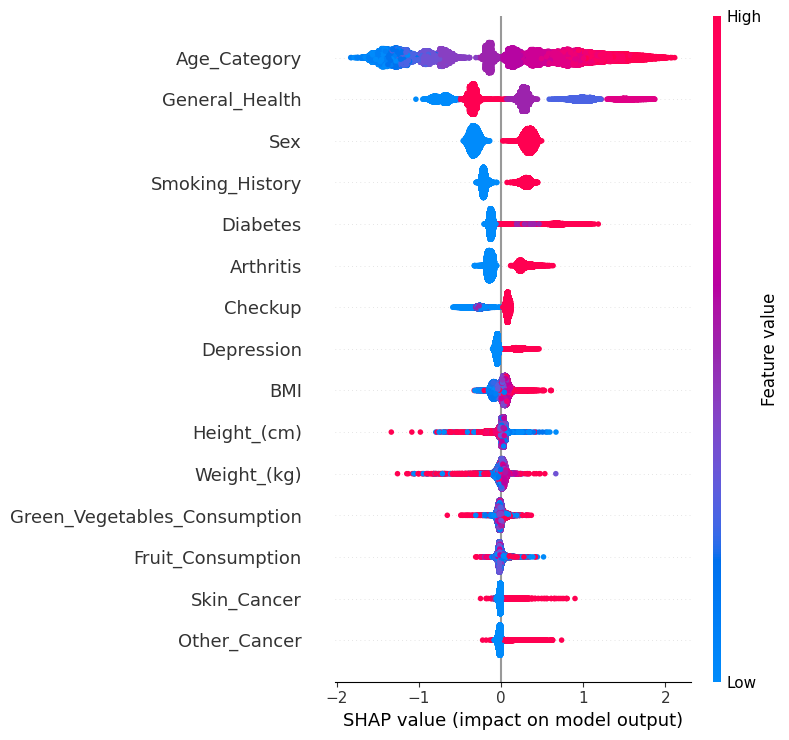

In [85]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sel, show=False)
plt.tight_layout()
plt.show()

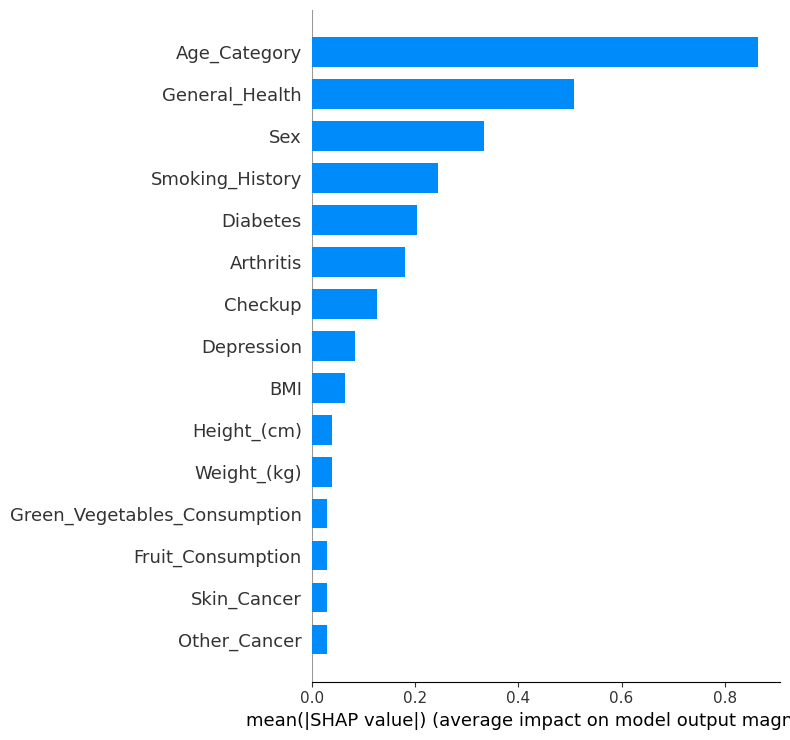

In [86]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sel, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

In [87]:
import numpy as np
import pandas as pd

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": X_test_sel.columns,
    "MeanAbsSHAP": mean_abs_shap
}).sort_values(by="MeanAbsSHAP", ascending=False)

shap_importance

,Feature,MeanAbsSHAP
8,Age_Category,0.863566
0,General_Health,0.507522
7,Sex,0.334432
12,Smoking_History,0.244637
5,Diabetes,0.203723
6,Arthritis,0.180388
1,Checkup,0.126683
4,Depression,0.084205
11,BMI,0.064735
9,Height_(cm),0.039798


In [88]:
import os

SAVE_DIR = "HGWGO_AAME_Final_Outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

print("Folder created:", SAVE_DIR)

Folder created: HGWGO_AAME_Final_Outputs


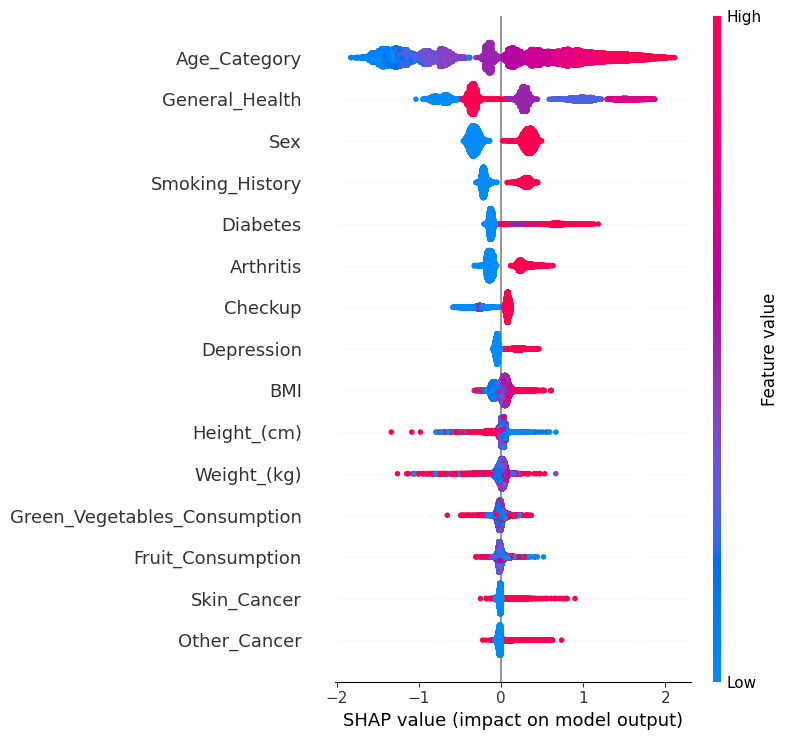

In [89]:
import matplotlib.pyplot as plt
import shap

# SHAP summary beeswarm plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sel, show=False)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/SHAP_Summary_Beeswarm.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{SAVE_DIR}/SHAP_Summary_Beeswarm.jpeg", dpi=300, bbox_inches='tight')
plt.savefig(f"{SAVE_DIR}/SHAP_Summary_Beeswarm.tiff", dpi=300, bbox_inches='tight')

plt.show()

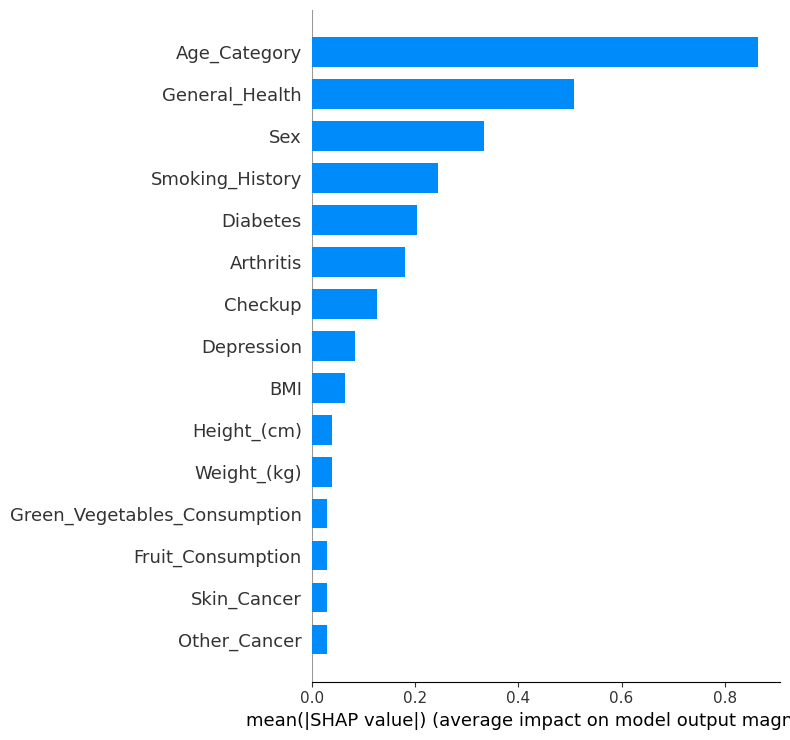

In [90]:
# SHAP bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sel, plot_type="bar", show=False)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/SHAP_Bar_Plot.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{SAVE_DIR}/SHAP_Bar_Plot.jpeg", dpi=300, bbox_inches='tight')
plt.savefig(f"{SAVE_DIR}/SHAP_Bar_Plot.tiff", dpi=300, bbox_inches='tight')

plt.show()

In [91]:
shap_importance.to_csv(f"{SAVE_DIR}/SHAP_Importance_Table.csv", index=False)

print("Saved: SHAP_Importance_Table.csv")

Saved: SHAP_Importance_Table.csv


In [92]:
baseline_results = pd.DataFrame({
    "Model": ["RF", "XGB", "CAT", "ET"],
    "AUROC": [0.8223, 0.8378, 0.8406, 0.8101],
    "Best_F1": [0.3572, 0.3689, 0.3751, 0.3356],
    "Best_MCC": [0.3079, 0.3221, 0.3307, 0.2717],
    "Best_Threshold": [0.15, 0.15, 0.15, 0.20]
})

baseline_results.to_csv(f"{SAVE_DIR}/Baseline_Results.csv", index=False)
baseline_results

,Model,AUROC,Best_F1,Best_MCC,Best_Threshold
0,RF,0.8223,0.3572,0.3079,0.15
1,XGB,0.8378,0.3689,0.3221,0.15
2,CAT,0.8406,0.3751,0.3307,0.15
3,ET,0.8101,0.3356,0.2717,0.20


In [93]:
history_df.to_csv(f"{SAVE_DIR}/HGWGO_Optimization_History.csv", index=False)

print("Saved: HGWGO_Optimization_History.csv")

Saved: HGWGO_Optimization_History.csv


In [94]:
selected_features_df = pd.DataFrame({
    "Selected_Features": selected_features
})

selected_features_df.to_csv(f"{SAVE_DIR}/HGWGO_Selected_Features.csv", index=False)
selected_features_df

,Selected_Features
0,General_Health
1,Checkup
2,Skin_Cancer
3,Other_Cancer
4,Depression
5,Diabetes
6,Arthritis
7,Sex
8,Age_Category
9,Height_(cm)


In [95]:
comparison_df.to_csv(f"{SAVE_DIR}/HGWGO_Model_Comparison.csv", index=False)

print("Saved: HGWGO_Model_Comparison.csv")
comparison_df

Saved: HGWGO_Model_Comparison.csv


,Model,Full_AUROC,Full_F1,Full_MCC,HGWGO_AUROC,HGWGO_F1,HGWGO_MCC
0,CatBoost,0.8406,0.3751,0.3307,0.839509,0.373446,0.328404
1,XGBoost,0.8378,0.3689,0.3221,0.835488,0.364483,0.316922
2,RandomForest,0.8223,0.3572,0.3079,0.810979,0.336296,0.281441


In [96]:
aame_results = pd.DataFrame({
    "Model": ["HGWGO_CatBoost", "Weighted_AAME", "Meta_AAME"],
    "AUROC": [0.8395094161971657, 0.8380594088921928, 0.8393332724062307],
    "F1":    [0.37344598672299334, 0.3691695793660359, 0.3695652173913043],
    "MCC":   [0.32840396356137086, 0.32313330861927886, 0.309347770285122]
})

aame_results.to_csv(f"{SAVE_DIR}/AAME_Results.csv", index=False)
aame_results

,Model,AUROC,F1,MCC
0,HGWGO_CatBoost,0.839509,0.373446,0.328404
1,Weighted_AAME,0.838059,0.369170,0.323133
2,Meta_AAME,0.839333,0.369565,0.309348


In [97]:
import joblib

# Final selected-feature models
joblib.dump(cat_sel, f"{SAVE_DIR}/cat_sel.pkl")
joblib.dump(xgb_sel, f"{SAVE_DIR}/xgb_sel.pkl")
joblib.dump(rf_sel,  f"{SAVE_DIR}/rf_sel.pkl")

# Final AAME meta-model if available
if 'meta_model' in globals():
    joblib.dump(meta_model, f"{SAVE_DIR}/meta_model.pkl")

# Selected feature list
joblib.dump(selected_features, f"{SAVE_DIR}/selected_features.pkl")

# Save datasets used in final phase
joblib.dump(X_train_sel, f"{SAVE_DIR}/X_train_sel.pkl")
joblib.dump(X_test_sel,  f"{SAVE_DIR}/X_test_sel.pkl")
joblib.dump(y_train,     f"{SAVE_DIR}/y_train.pkl")
joblib.dump(y_test,      f"{SAVE_DIR}/y_test.pkl")

print("All important .pkl files saved.")

All important .pkl files saved.


In [98]:
with open(f"{SAVE_DIR}/Final_Best_Model_Summary.txt", "w") as f:
    f.write("FINAL BEST MODEL: HGWGO-selected CatBoost\n")
    f.write("=========================================\n\n")

    f.write("Performance:\n")
    f.write("AUROC : 0.8395094161971657\n")
    f.write("F1    : 0.37344598672299334\n")
    f.write("MCC   : 0.32840396356137086\n\n")

    f.write("Selected Features (15):\n")
    for feat in selected_features:
        f.write(f"- {feat}\n")

print("Saved: Final_Best_Model_Summary.txt")

Saved: Final_Best_Model_Summary.txt


In [99]:
import zipfile

zip_path = "HGWGO_AAME_Final_Outputs.zip"

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(SAVE_DIR):
        for file in files:
            file_path = os.path.join(root, file)
            zipf.write(file_path)

print("ZIP file created:", zip_path)

ZIP file created: HGWGO_AAME_Final_Outputs.zip


In [100]:
from google.colab import files
files.download("HGWGO_AAME_Final_Outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>